# Make figures for the any-dimensional presentation

In [1]:
%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=6

import matplotlib.pyplot as plt
import numpy as np

import jax.numpy as jnp
from jax import random
import jax

import ginjax.geometric as geom
import ginjax.utils as utils

%load_ext autoreload
%autoreload 2

env: CUDA_DEVICE_ORDER=PCI_BUS_ID
env: CUDA_VISIBLE_DEVICES=6


In [2]:

def heat_step(D: int, x0: jax.Array, t: float, k: float, is_torus: bool) -> jax.Array:
    """
    Given the initial temperature, time, and diffusion coefficient, calculate the new heat field.

    args:
        D: the dimension
        x0: the starting temperature array, shape (batch, spatial)
        t: the length of the timestep
        k: diffusion coefficient
        is_torus: whether the data lives on the torus

    returns:
        the heat field after time t
    """
    assert t >= 0
    if t == 0:
        return x0

    batch = len(x0)
    spatial_dims = x0.shape[1:]
    x0_flat = x0.reshape((batch, -1))
    meshgrid_dims = (jnp.arange(N) for N in spatial_dims)

    # (spatial_size,D)
    idxs = jnp.stack(jnp.meshgrid(*meshgrid_dims, indexing="ij"), axis=-1).reshape((-1, D))
    x1 = []
    for i, idx in enumerate(idxs):
        # (spatial_size,D)
        if is_torus:
            idxs_diff = jnp.abs(idxs - idx[None])
            idxs_diff_wrapped = jnp.stack(spatial_dims).reshape((1, D)) - idxs_diff
            dist = jnp.where(idxs_diff < idxs_diff_wrapped, idxs_diff, idxs_diff_wrapped)
        else:
            dist = idxs - idx[None]

        # (1,spatial_size)
        heat_kernel = jnp.exp((jnp.linalg.norm(dist, axis=1) ** 2) / (-4 * k * t))[None]

        x1.append(jnp.sum(heat_kernel * x0_flat, axis=1) / ((4 * jnp.pi * k * t) ** (D / 2)))

    return jnp.stack(x1, axis=1).reshape(x0.shape)


def get_data_d(
    D: int,
    N: int,
    is_torus: bool,
    k: float,
    t: float,
    max_temp: float,
    batch: int,
    key: jax.Array,
) -> tuple[geom.MultiImage, geom.MultiImage]:
    """
    Get an input, output data pair of heat diffusion after t timestep, diffusion coefficient k.
    The initial data is uniform on the range 0 to max_temp.

    args:
        D: the dimension of the space
        N: sidelength of a cube of data
        is_torus: whether the data is on the torus
        k: diffusion coefficient
        t: size of timestep
        max_temp: max temperature
        batch: number of data points
        key: key for randomness

    returns:
        input multi image, output multi image
    """
    key, subkey = random.split(key)
    # x0 = random.normal(subkey, shape=(batch,) + (N,) * D)
    # for max_temp = sqrt(3), this has mean=0, stdev=1 for any dimension
    x0 = random.uniform(subkey, shape=(batch,) + (N,) * D, minval=-max_temp, maxval=max_temp)
    xt = heat_step(D, x0, t, k, is_torus)

    x0_img = geom.MultiImage({(0, 0): x0[:, None]}, D, is_torus)
    xt_img = geom.MultiImage({(0, 0): xt[:, None]}, D, is_torus)

    return x0_img, xt_img

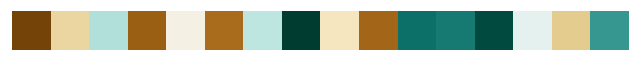

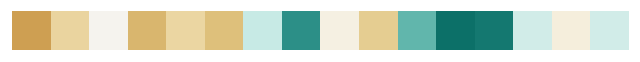

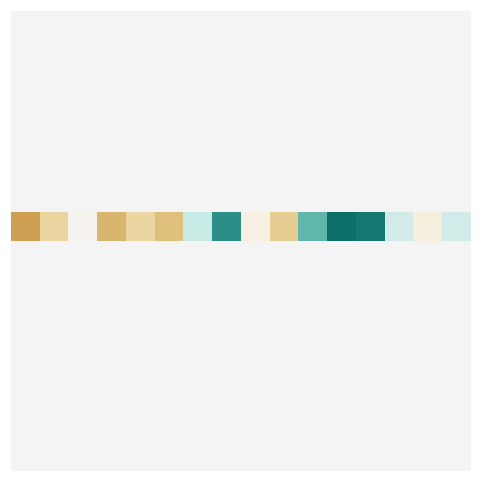

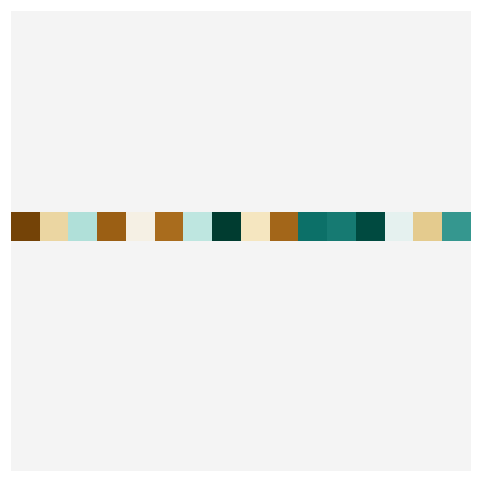

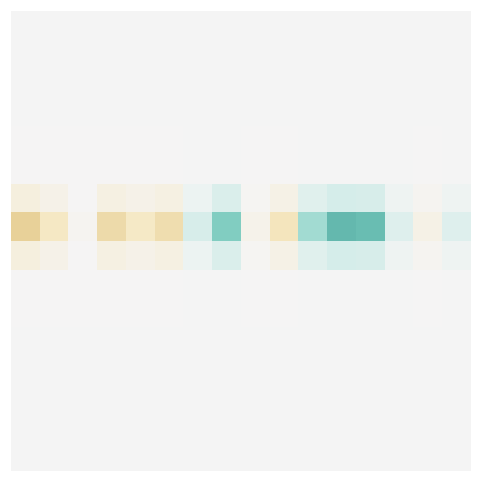

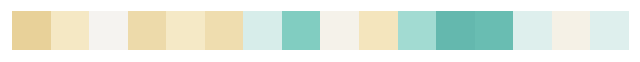

In [3]:
D = 1
N = 16
is_torus = True
key = random.PRNGKey(0)
diffusion_k = 0.2

key,subkey = random.split(key)
x0_d1, xt_d1 = get_data_d(D, N, is_torus, diffusion_k, 1, float(jnp.sqrt(3)), 1, subkey)
xt_d1_d2_data = jnp.zeros((1,1) + (N,)*2)
xt_d1_d2_data = xt_d1_d2_data.at[:,:,:,N//2].set(xt_d1[((),0)])
xt_d1_d2 = geom.MultiImage({(0,0): xt_d1_d2_data}, 2, True)

x0_d2_data = jnp.zeros((1,1) + (N,)*2)
x0_d2_data = x0_d2_data.at[:,:,:,N//2].set(x0_d1[((),0)])
x0_d2 = geom.MultiImage({(0,0): x0_d2_data}, 2, True)

xt_d2 = geom.MultiImage(
    {(0,0): heat_step(2, x0_d2_data[:,0], 1, diffusion_k, is_torus)[:,None]}, 
    2, 
    x0_d2.is_torus,
)

xt_d2_sliver = geom.MultiImage({(0,0): xt_d2[((),0)][:,:,:,N//2]}, 1, is_torus)

all_data = jnp.concatenate([
    x0_d1.to_vector().ravel(), 
    xt_d1.to_vector().ravel(), 
    xt_d1_d2.to_vector().ravel(),
    x0_d2.to_vector().ravel(),
    xt_d2.to_vector().ravel(),
    xt_d2_sliver.to_vector().ravel(),
])
vmax = float(jnp.max(jnp.abs(all_data)))

x0_d1.to_images()[0].plot(vmin=-vmax, vmax=vmax)
xt_d1.to_images()[0].plot(vmin=-vmax, vmax=vmax)
xt_d1_d2.to_images()[0].plot(vmin=-vmax, vmax=vmax)

x0_d2.to_images()[0].plot(vmin=-vmax, vmax=vmax)
xt_d2.to_images()[0].plot(vmin=-vmax, vmax=vmax)
xt_d2_sliver.to_images()[0].plot(vmin=-vmax, vmax=vmax)

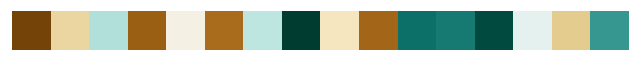

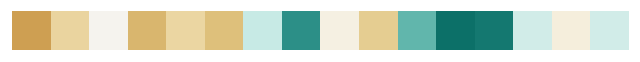

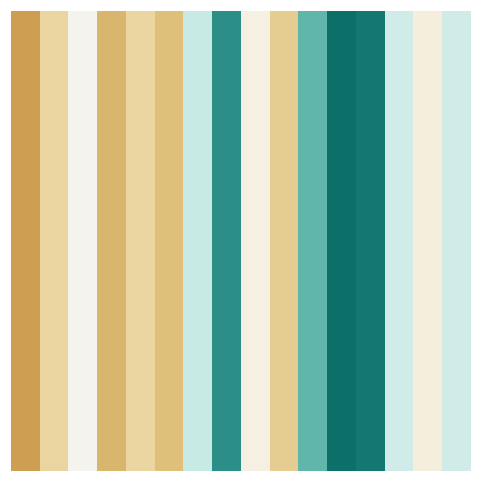

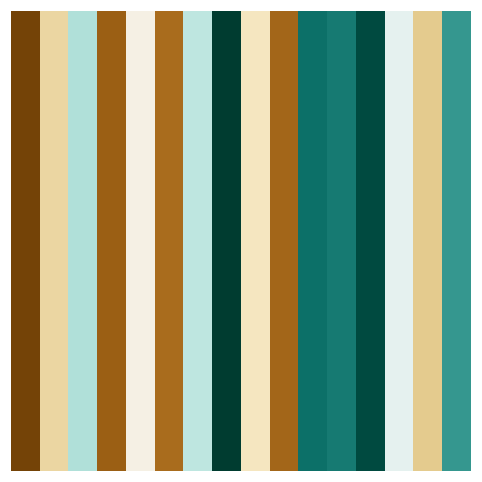

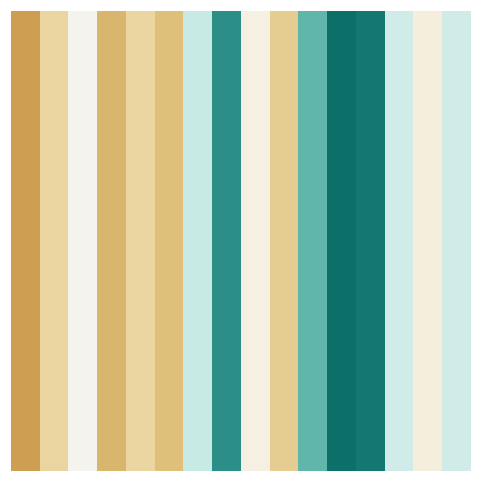

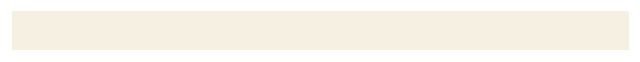

In [4]:
D = 1
N = 16
is_torus = True
key = random.PRNGKey(0)
diffusion_k = 0.2

key,subkey = random.split(key)
x0_d1, xt_d1 = get_data_d(D, N, is_torus, diffusion_k, 1, float(jnp.sqrt(3)), 1, subkey)
xt_d1_d2_data = jnp.full((1,1) + (N,)*2, xt_d1[((),0)].reshape((1,1,N,1)))
xt_d1_d2 = geom.MultiImage({(0,0): xt_d1_d2_data}, 2, True)

x0_d2_data = jnp.full((1,1) + (N,)*2, x0_d1[((),0)].reshape((1,1,N,1)))
x0_d2 = geom.MultiImage({(0,0): x0_d2_data}, 2, True)

xt_d2 = geom.MultiImage(
    {(0,0): heat_step(2, x0_d2_data[:,0], 1, diffusion_k, is_torus)[:,None]}, 
    2, 
    x0_d2.is_torus,
)

xt_d2_sliver = geom.MultiImage({(0,0): xt_d2[((),0)][:,:,N//2,:]}, 1, is_torus)

all_data = jnp.concatenate([
    x0_d1.to_vector().ravel(), 
    xt_d1.to_vector().ravel(), 
    xt_d1_d2.to_vector().ravel(),
    x0_d2.to_vector().ravel(),
    xt_d2.to_vector().ravel(),
    xt_d2_sliver.to_vector().ravel(),
])
vmax = float(jnp.max(jnp.abs(all_data)))

x0_d1.to_images()[0].plot(vmin=-vmax, vmax=vmax)
xt_d1.to_images()[0].plot(vmin=-vmax, vmax=vmax)
xt_d1_d2.to_images()[0].plot(vmin=-vmax, vmax=vmax)

x0_d2.to_images()[0].plot(vmin=-vmax, vmax=vmax)
xt_d2.to_images()[0].plot(vmin=-vmax, vmax=vmax)
xt_d2_sliver.to_images()[0].plot(vmin=-vmax, vmax=vmax)

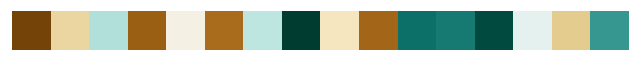

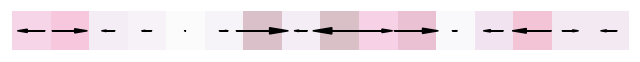

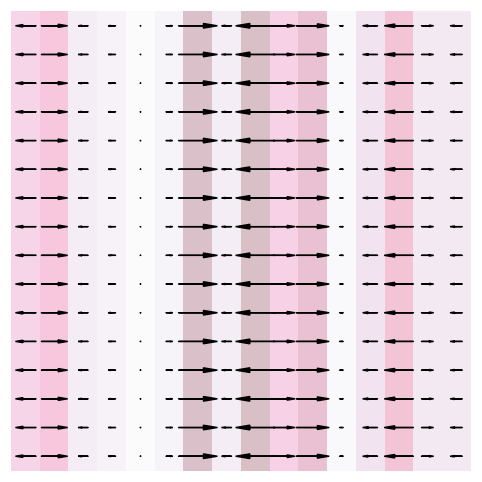

In [30]:
# now we want to find the gradient
D = 1

x0_d1.to_images()[0].plot(vmin=-vmax, vmax=vmax)
x0_d1_img = x0_d1.to_images()[0]
left_shift = x0_d1_img.translate(jnp.array([-1]))
right_shift = x0_d1_img.translate(jnp.array([1]))

left_difference = (x0_d1_img - left_shift)*-1
right_difference = x0_d1_img - right_shift

net_diff_vector = (left_difference.data + right_difference.data)[...,None] / 2
vec_vmax = float(jnp.max(jnp.abs(net_diff_vector)))

grad_d1_img = geom.GeometricImage(net_diff_vector, 0, D)
grad_d1_img.plot(vmax=vec_vmax)

zero_pad_vec = jnp.concatenate([net_diff_vector, jnp.zeros_like(net_diff_vector)], axis=-1) # zero pad the tensor
grad_d2_img = geom.GeometricImage(jnp.full((N,N,2), zero_pad_vec.reshape((N,1,2))), 0, 2)
grad_d2_img.plot(vmax=vec_vmax)

